<a href="https://colab.research.google.com/github/LuanLindolfo/machinelearning/blob/Regressao/Regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning e Data Science com Python de A à Z IA Expert Academy - Regressão

# Regressão linear simples

## Base plano saúde

In [ ]:
!pip install plotly --upgrade

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns #para visualizacao do grafico
import matplotlib.pyplot as plt #importação de dados
import pandas as pd #para carregar o csv
import numpy as np #biblioteca cientifica

In [ ]:
base_plano_saude = pd.read_csv('plano_saude.csv')
base_plano_saude

,idade,custo
0,18,871
1,23,1132
2,28,1242
3,33,1356
4,38,1488
5,43,1638
6,48,2130
7,53,2454
8,58,3066
9,63,4090


In [ ]:
#duas variaveis para o atributo previsor e outra pro objetivo
#para teste e treinamento
X_plano_saude = base_plano_saude.iloc[:, 0].values
#iloc - para selecionar um conjunto de registros
#:, 0 - todas as linhas, coluna 0
X_plano_saude

array([18, 23, 28, 33, 38, 43, 48, 53, 58, 63])

In [ ]:
y_plano_saude = base_plano_saude.iloc[:, 1].values
#iloc - para selecionar um conjunto de registros
#:, 0 - todas as linhas, coluna 1
y_plano_saude

array([ 871, 1132, 1242, 1356, 1488, 1638, 2130, 2454, 3066, 4090])

In [ ]:
np.corrcoef(X_plano_saude, y_plano_saude)#coeficiente de correlação

array([[1.        , 0.93091958],
       [0.93091958, 1.        ]])

In [ ]:
X_plano_saude.shape#vendo o formato da variavel
#matriz com uma dimensao

(10,)

In [ ]:
X_plano_saude = X_plano_saude.reshape(-1,1)
#vendo o formato da variavel
#matriz com duas dimensoes
X_plano_saude.shape

(10, 1)

In [ ]:
from sklearn.linear_model import LinearRegression
#LinearRegression - regressão linear
regressor_plano_saude = LinearRegression()
regressor_plano_saude.fit(X_plano_saude, y_plano_saude)#treinamento

LinearRegression()

In [ ]:
# b0
regressor_plano_saude.intercept_ #inicio da linha de regressao

np.float64(-558.9490909090912)

In [ ]:
# b1
regressor_plano_saude.coef_ #declive da linha

array([61.86787879])

In [ ]:
previsoes = regressor_plano_saude.predict(X_plano_saude)
previsoes #formula aplicada
#previsoes das idades

array([ 554.67272727,  864.01212121, 1173.35151515, 1482.69090909,
       1792.03030303, 2101.36969697, 2410.70909091, 2720.04848485,
       3029.38787879, 3338.72727273])

In [ ]:
X_plano_saude.ravel()
#.ravel() - de matriz vira vetor simples

array([18, 23, 28, 33, 38, 43, 48, 53, 58, 63])

In [ ]:
grafico = px.scatter(x = X_plano_saude.ravel(), y = y_plano_saude)
grafico.add_scatter(x = X_plano_saude.ravel(), y = previsoes, name = 'Regressão')
grafico.show()

In [ ]:
regressor_plano_saude.intercept_ + regressor_plano_saude.coef_ * 40
#de onde vem os valores
#aplicacao da formula linear
#b0 + b1 * x

array([1915.76606061])

In [ ]:
regressor_plano_saude.predict([[40]]) #transformando o regressor em matriz

array([1915.76606061])

In [ ]:
regressor_plano_saude.score(X_plano_saude, y_plano_saude)#score pra calcular a qualidade do algoritmo
#mais proximo de 1, melhor o valor

0.8666112727879174

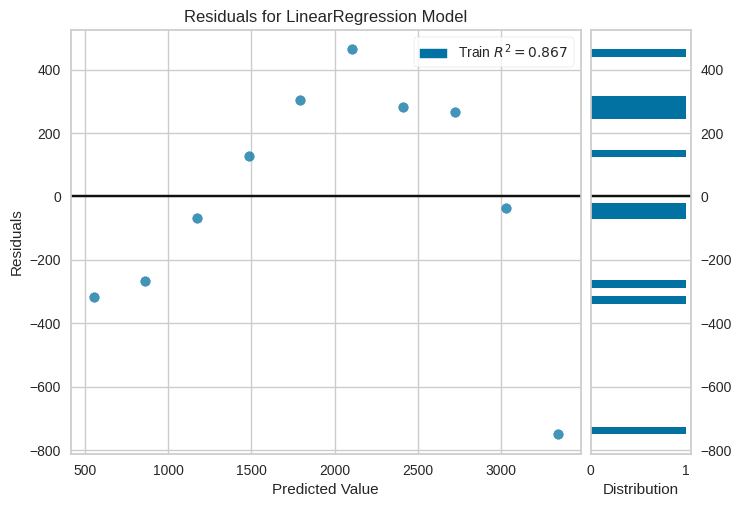

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [ ]:
from yellowbrick.regressor import ResidualsPlot #vendo os residuais
visualizador = ResidualsPlot(regressor_plano_saude)
visualizador.fit(X_plano_saude, y_plano_saude)
visualizador.poof()#gerando o gráfico dos residuais - quanto os dados tão afastados da linha de regressão

## Base preço das casas - MAE 172.604, 0.48

In [ ]:
base_casas = pd.read_csv('house_prices.csv')
base_casas
#price (preço da casa) -> atributo objetivo
#ver a linearidade do valor da casa conforme o tamanho

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
# ATUALIZAÇÃO OUT-2024: a versão atual do Pandas não está considerando o formato do dado como data, vamos remover esta coluna
base_casas.drop('date', axis=1, inplace=True)

In [ ]:
base_casas.describe()#estatisticas

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
base_casas.isnull().sum()
#isnull() - vendo se há valores faltantes
#.sum() - retorna o somatorio dos valores faltantes
#constou 0 faltantes, logo, nao precisa de tratamento

,0
id,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
base_casas.corr()
#correlação de um atributo com todos os outros

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


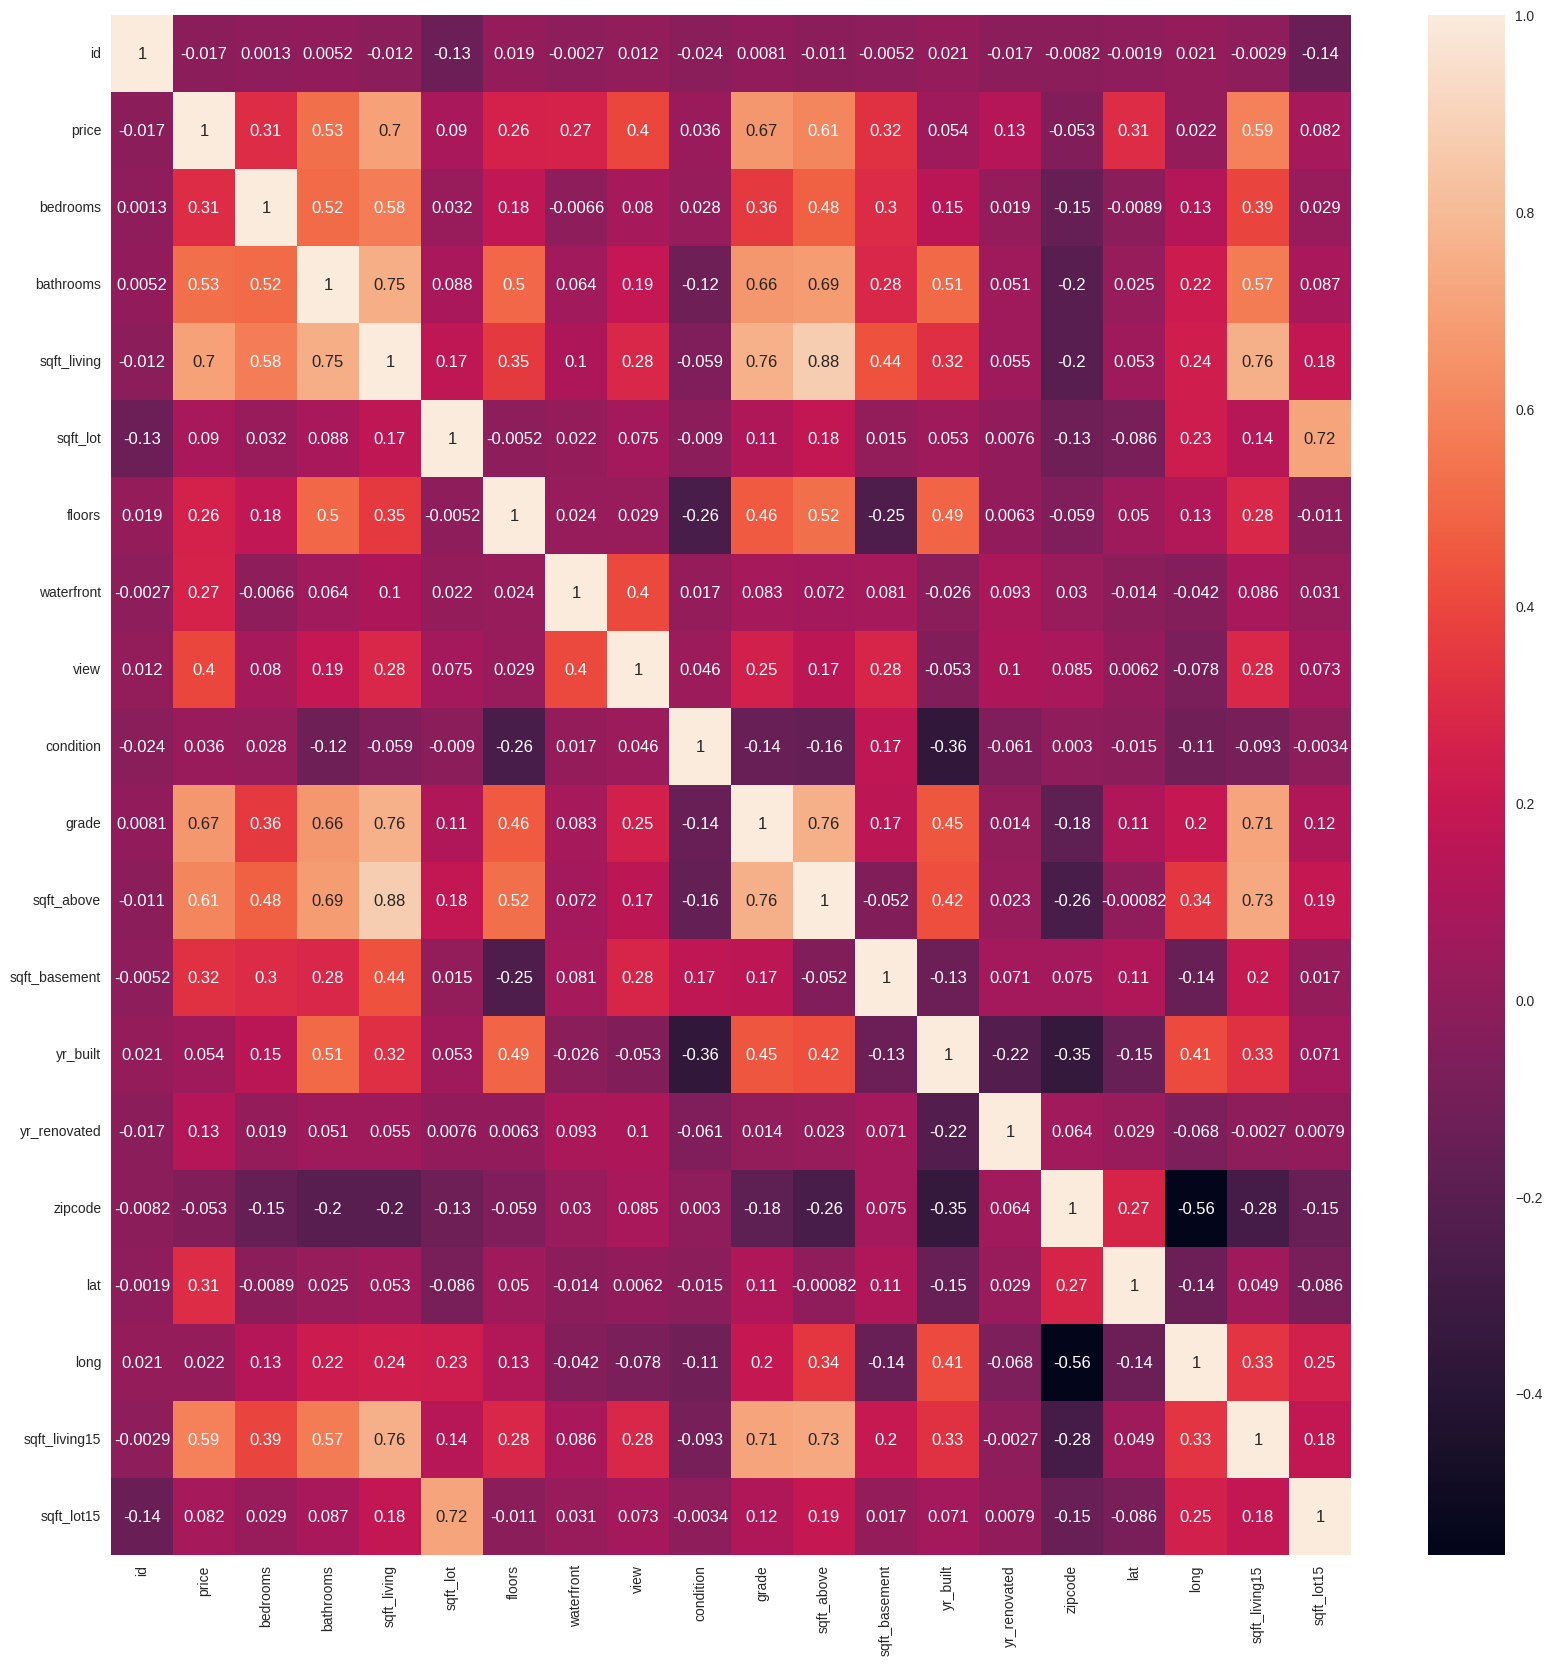

In [ ]:
figura = plt.figure(figsize=(20,20))
sns.heatmap(base_casas.corr(), annot=True);
#vendo a correlação plotada

In [ ]:
X_casas = base_casas.iloc[:,5:6].values #criando a variavel com das colunas 5 a 6
#busca somente a coluna 5 (mettragem da casa -> previsor)
X_casas

array([[ 5650],
       [ 7242],
       [10000],
       ...,
       [ 1350],
       [ 2388],
       [ 1076]])

In [ ]:
y_casas = base_casas.iloc[:, 2].values
y_casas

array([3, 3, 2, ..., 2, 3, 2])

In [ ]:
#criando o modelo da previsao do preço com base na metragem
from sklearn.model_selection import train_test_split
#30% pra testar e 70% para treinar
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(X_casas, y_casas, test_size = 0.3, random_state = 0)

In [ ]:
X_casas_treinamento.shape, y_casas_treinamento.shape#treinamento

((15129, 1), (15129,))

In [ ]:
X_casas_teste.shape, y_casas_teste.shape#teste

((6484, 1), (6484,))

In [ ]:
#encaixando os dados na regresão linear
from sklearn.linear_model import LinearRegression
regressor_simples_casas = LinearRegression()
regressor_simples_casas.fit(X_casas_treinamento, y_casas_treinamento)

LinearRegression()

In [ ]:
# b0
regressor_simples_casas.intercept_

np.float64(3.355183935781682)

In [ ]:
# b1
regressor_simples_casas.coef_

array([6.79426782e-07])

In [ ]:
regressor_simples_casas.score(X_casas_treinamento, y_casas_treinamento)#avaliação na base de dados do treinamento

0.000920509971809147

In [ ]:
regressor_simples_casas.score(X_casas_teste, y_casas_teste)#avaliação na base de dados do teste

0.0008220249628060339

In [ ]:
previsoes = regressor_simples_casas.predict(X_casas_treinamento)
#.predict - executa a fórmula da regressão linear simples
previsoes

array([3.36007581, 3.36015462, 3.35883857, ..., 3.36534137, 3.40727219,
       3.36621511])

In [ ]:
grafico = px.scatter(x = X_casas_treinamento.ravel(), y = previsoes)
grafico.show()

In [ ]:
#treinamento e respostas reais
grafico1 = px.scatter(x = X_casas_treinamento.ravel(), y = y_casas_treinamento)
grafico2 = px.line(x = X_casas_treinamento.ravel(), y = previsoes)
grafico2.data[0].line.color = 'red'
grafico3 = go.Figure(data=grafico1.data + grafico2.data)
#concatenando os dois gráficos
grafico3
#azul - respotas real
#vermelho - previsões

In [ ]:
previsoes_teste = regressor_simples_casas.predict(X_casas_teste)
previsoes_teste
#previsoes para cada uma das casas

array([3.35630499, 3.3904027 , 3.35769781, ..., 3.3726486 , 3.36062546,
       3.36146116])

In [ ]:
y_casas_teste #valores reais

array([2, 4, 2, ..., 3, 3, 3])

In [ ]:
abs(y_casas_teste - previsoes_teste).mean()#subtração de casa por casa (querendo saber a diferença), desconsiderando se é negativo ou não
#abs - pega o valor absoluto e desconsidera o sinal
#erro para cima ou para baixo

np.float64(0.7217139313807803)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
mean_absolute_error(y_casas_teste, previsoes_teste)#Mean Absolute Error

0.7217139313807803

In [ ]:
mean_squared_error(y_casas_teste, previsoes_teste)#Mean Squared Error

0.8004859591383177

In [ ]:
np.sqrt(mean_squared_error(y_casas_teste, previsoes_teste))#Root Mean Squared Error

np.float64(0.8946988091745276)

In [ ]:
#plotando os dados com a base de dados do teste
grafico1 = px.scatter(x = X_casas_teste.ravel(), y = y_casas_teste)
grafico2 = px.line(x = X_casas_teste.ravel(), y = previsoes_teste)
grafico2.data[0].line.color = 'red'
grafico3 = go.Figure(data=grafico1.data + grafico2.data)
grafico3.show()

# Regressão linear múltipla

## Base preço das casas - MAE 123.888, 0.68

In [ ]:
base_casas

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
X_casas = base_casas.iloc[:, 3:19].values #todos os registros (:), da coluna de 3 a 19
X_casas

array([[ 1.00000e+00,  1.18000e+03,  5.65000e+03, ...,  4.75112e+01,
        -1.22257e+02,  1.34000e+03],
       [ 2.25000e+00,  2.57000e+03,  7.24200e+03, ...,  4.77210e+01,
        -1.22319e+02,  1.69000e+03],
       [ 1.00000e+00,  7.70000e+02,  1.00000e+04, ...,  4.77379e+01,
        -1.22233e+02,  2.72000e+03],
       ...,
       [ 7.50000e-01,  1.02000e+03,  1.35000e+03, ...,  4.75944e+01,
        -1.22299e+02,  1.02000e+03],
       [ 2.50000e+00,  1.60000e+03,  2.38800e+03, ...,  4.75345e+01,
        -1.22069e+02,  1.41000e+03],
       [ 7.50000e-01,  1.02000e+03,  1.07600e+03, ...,  4.75941e+01,
        -1.22299e+02,  1.02000e+03]])

In [ ]:
y_casas = base_casas.iloc[:, 2].values #todos os registros somente a coluna 2
y_casas

array([3, 3, 2, ..., 2, 3, 2])

In [ ]:
from sklearn.model_selection import train_test_split
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(X_casas, y_casas, test_size = 0.3, random_state = 0)

In [ ]:
X_casas_treinamento.shape, X_casas_teste.shape #treinamento e teste

((15129, 16), (6484, 16))

In [ ]:
regressor_multiplo_casas = LinearRegression() #criando o regressor
regressor_multiplo_casas.fit(X_casas_treinamento, y_casas_treinamento)#encaixando os dados

LinearRegression()

In [ ]:
regressor_multiplo_casas.intercept_ #b0
#.intercept_ -> representa o b0

np.float64(81.35599994951795)

In [ ]:
regressor_multiplo_casas.coef_
#.coef_ coeficientes para cada atributo da lista

array([ 3.40168475e-01,  4.04400641e-04, -1.41708149e-06, -4.66608213e-02,
       -4.16007891e-01, -8.90480934e-02,  5.43724979e-02, -1.45010063e-01,
        1.83085357e-04,  2.21315284e-04, -2.30619947e-03, -5.20881810e-05,
       -7.92854871e-04, -1.73729715e-01, -9.58217567e-02, -1.94871400e-05])

In [ ]:
len(regressor_multiplo_casas.coef_)#16 atributos previsores (Xn)

16

In [ ]:
regressor_multiplo_casas.score(X_casas_treinamento, y_casas_treinamento) #regressor

0.3911299083979677

In [ ]:
regressor_multiplo_casas.score(X_casas_teste, y_casas_teste) #score na base de test

0.3985615256409738

In [ ]:
previsoes = regressor_multiplo_casas.predict(X_casas_teste)
previsoes
#previsões

array([2.70251894, 4.57515624, 2.77900062, ..., 3.65848588, 3.09187509,
       2.76556214])

In [ ]:
y_casas_teste #teste
#para fins de comparação

array([2, 4, 2, ..., 3, 3, 3])

In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_teste, previsoes)

0.5275996524121869

# Regressão polinomial

## Base plano de saúde

In [ ]:
base_plano_saude2 = pd.read_csv('plano_saude2.csv')
#base com a mesma estrutura do anterior mas os dados estão em formato de curva
base_plano_saude2

,idade,custo
0,18,470
1,23,520
2,28,630
3,33,830
4,38,1150
5,43,1530
6,48,2040
7,53,3080
8,58,5100
9,63,10100


In [ ]:
X_plano_saude2 = base_plano_saude2.iloc[:, 0:1].values#previsor - : -> todos, 0:1 -> 0 até 1 (só a 0)
y_plano_saude2 = base_plano_saude2.iloc[:, 1].values#resposta esperada - : -> todos, 1 -> coluna 1

In [ ]:
X_plano_saude2

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [ ]:
y_plano_saude2 #elevando ao quadrado da fórmula da regressão linear multipla para cada um dos atributos

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 4)
#poly = PolynomialFeatures -> polinomial (multiplos polinômios)
#(degree = 4) -> quantas vezer que fazer a elevação, nesse caso 4
#4 atributo para cada um dos fatores
X_plano_saude2_poly = poly.fit_transform(X_plano_saude2)
#encaixando os dados

In [ ]:
X_plano_saude2_poly.shape
#10 registros e 5 atributos

(10, 5)

In [ ]:
18 * 18, 18 * 18 * 18, 18 * 18 * 18 * 18

(324, 5832, 104976)

In [ ]:
X_plano_saude2_poly[0]
#valor padrão, valor original e valor ao quadrado

array([1.00000e+00, 1.80000e+01, 3.24000e+02, 5.83200e+03, 1.04976e+05])

In [ ]:
23 * 23

529

In [ ]:
X_plano_saude2_poly[1]
#valor padrão, valor original e valor ao quadrado

array([1.00000e+00, 2.30000e+01, 5.29000e+02, 1.21670e+04, 2.79841e+05])

In [ ]:
X_plano_saude2_poly #dados que serão enviados ao algoritmo de regressão linear

array([[1.0000000e+00, 1.8000000e+01, 3.2400000e+02, 5.8320000e+03,
        1.0497600e+05],
       [1.0000000e+00, 2.3000000e+01, 5.2900000e+02, 1.2167000e+04,
        2.7984100e+05],
       [1.0000000e+00, 2.8000000e+01, 7.8400000e+02, 2.1952000e+04,
        6.1465600e+05],
       [1.0000000e+00, 3.3000000e+01, 1.0890000e+03, 3.5937000e+04,
        1.1859210e+06],
       [1.0000000e+00, 3.8000000e+01, 1.4440000e+03, 5.4872000e+04,
        2.0851360e+06],
       [1.0000000e+00, 4.3000000e+01, 1.8490000e+03, 7.9507000e+04,
        3.4188010e+06],
       [1.0000000e+00, 4.8000000e+01, 2.3040000e+03, 1.1059200e+05,
        5.3084160e+06],
       [1.0000000e+00, 5.3000000e+01, 2.8090000e+03, 1.4887700e+05,
        7.8904810e+06],
       [1.0000000e+00, 5.8000000e+01, 3.3640000e+03, 1.9511200e+05,
        1.1316496e+07],
       [1.0000000e+00, 6.3000000e+01, 3.9690000e+03, 2.5004700e+05,
        1.5752961e+07]])

In [ ]:
regressor_saude_polinomial = LinearRegression() #regressão
regressor_saude_polinomial.fit(X_plano_saude2_poly, y_plano_saude2)#encaixando os dados

LinearRegression()

In [ ]:
# b0
regressor_saude_polinomial.intercept_

np.float64(16561.97463791193)

In [ ]:
# b1 (n)
regressor_saude_polinomial.coef_

array([ 0.00000000e+00, -2.12242253e+03,  9.90404199e+01, -1.95058276e+00,
        1.40792541e-02])

In [ ]:
novo = [[40]]

In [ ]:
novo = poly.transform(novo)
novo

array([[1.00e+00, 4.00e+01, 1.60e+03, 6.40e+04, 2.56e+06]])

In [ ]:
regressor_saude_polinomial.predict(novo)

array([1335.33958015])

In [ ]:
previsoes = regressor_saude_polinomial.predict(X_plano_saude2_poly)
previsoes

array([ 549.65035464,  345.85081575,  616.53845992,  975.8391595 ,
       1249.06759853, 1472.7272727 , 1894.51048941, 2973.2983677 ,
       5379.16083828, 9993.35664357])

In [ ]:
grafico = px.scatter(x = X_plano_saude2[:,0], y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2[:,0], y = previsoes, name = 'Regressão')
grafico.show()

## Base preço das casas - MAE 101.225, 0.81

In [ ]:
#regressão multipla na base de dados das casas
X_casas_treinamento.shape

(15129, 16)

In [ ]:
X_casas_teste.shape

(6484, 16)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2)
#(degree = 2) -> elevando o atributo original ao quadrado
X_casas_treinamento_poly = poly.fit_transform(X_casas_treinamento)
X_casas_teste_poly = poly.transform(X_casas_teste)

In [ ]:
X_casas_treinamento_poly.shape, X_casas_teste_poly.shape

((15129, 153), (6484, 153))

In [ ]:
regressor_casas_poly = LinearRegression()#criando o regressor
regressor_casas_poly.fit(X_casas_treinamento_poly, y_casas_treinamento)

LinearRegression()

In [ ]:
regressor_casas_poly.score(X_casas_treinamento_poly, y_casas_treinamento)

0.4626132037246721

In [ ]:
regressor_casas_poly.score(X_casas_teste_poly, y_casas_teste)

0.4551908450827745

In [ ]:
previsoes = regressor_casas_poly.predict(X_casas_teste_poly)
previsoes

array([2.58555719, 3.83712185, 2.68735084, ..., 3.44111196, 3.09850886,
       2.91668945])

In [ ]:
y_casas_teste

array([2, 4, 2, ..., 3, 3, 3])

In [ ]:
mean_absolute_error(y_casas_teste, previsoes)

0.49994730139162147

In [ ]:
#eu que fiz pra testar
grafico = px.scatter(x = X_casas_teste_poly[:,0], y = y_casas_teste)
grafico.add_scatter(x = X_casas_teste_poly[:,0], y = previsoes, name = 'Regressão')
grafico.show()

# Árvores de decisão

## Base plano saúde

In [ ]:
X_plano_saude2#idade

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [ ]:
y_plano_saude2#custo do plano de saúda

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [ ]:
from sklearn.tree import DecisionTreeRegressor #arvore de decisão em regressão
regressor_arvore_saude = DecisionTreeRegressor()
regressor_arvore_saude.fit(X_plano_saude2, y_plano_saude2)
#agora o criterio nao é entropia e sim o MSE, por estar em classificação (o algoritmo decidiu o melhor)

DecisionTreeRegressor()

In [ ]:
previsoes = regressor_arvore_saude.predict(X_plano_saude2)
previsoes

array([  470.,   520.,   630.,   830.,  1150.,  1530.,  2040.,  3080.,
        5100., 10100.])

In [ ]:
regressor_arvore_saude.score(X_plano_saude2, y_plano_saude2)#score 1 - quando os valores são todos iguais

1.0

In [ ]:
#gerando o gráfico - todos correspondentes aos pontos
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2.ravel(), y = previsoes, name = 'Regressão')
grafico.show()

In [ ]:
#para verificar os splits
#min e max - idade minima e máxima a base de dados indo de 0.1 em 0.1
X_teste_arvore = np.arange(min(X_plano_saude2), max(X_plano_saude2), 0.1)
X_teste_arvore

<ipython-input-91-363d57eac761>:3: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



array([18. , 18.1, 18.2, 18.3, 18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19. ,
       19.1, 19.2, 19.3, 19.4, 19.5, 19.6, 19.7, 19.8, 19.9, 20. , 20.1,
       20.2, 20.3, 20.4, 20.5, 20.6, 20.7, 20.8, 20.9, 21. , 21.1, 21.2,
       21.3, 21.4, 21.5, 21.6, 21.7, 21.8, 21.9, 22. , 22.1, 22.2, 22.3,
       22.4, 22.5, 22.6, 22.7, 22.8, 22.9, 23. , 23.1, 23.2, 23.3, 23.4,
       23.5, 23.6, 23.7, 23.8, 23.9, 24. , 24.1, 24.2, 24.3, 24.4, 24.5,
       24.6, 24.7, 24.8, 24.9, 25. , 25.1, 25.2, 25.3, 25.4, 25.5, 25.6,
       25.7, 25.8, 25.9, 26. , 26.1, 26.2, 26.3, 26.4, 26.5, 26.6, 26.7,
       26.8, 26.9, 27. , 27.1, 27.2, 27.3, 27.4, 27.5, 27.6, 27.7, 27.8,
       27.9, 28. , 28.1, 28.2, 28.3, 28.4, 28.5, 28.6, 28.7, 28.8, 28.9,
       29. , 29.1, 29.2, 29.3, 29.4, 29.5, 29.6, 29.7, 29.8, 29.9, 30. ,
       30.1, 30.2, 30.3, 30.4, 30.5, 30.6, 30.7, 30.8, 30.9, 31. , 31.1,
       31.2, 31.3, 31.4, 31.5, 31.6, 31.7, 31.8, 31.9, 32. , 32.1, 32.2,
       32.3, 32.4, 32.5, 32.6, 32.7, 32.8, 32.9, 33

In [ ]:
X_teste_arvore.shape

(450, 1)

In [ ]:
X_teste_arvore = X_teste_arvore.reshape(-1,1)#agora em matriz
X_teste_arvore.shape

(450, 1)

In [ ]:
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)#dados originais
grafico.add_scatter(x = X_teste_arvore.ravel(), y = regressor_arvore_saude.predict(X_teste_arvore), name = 'Regressão')
#previsões do algoritmo
#X_teste_arvore - para o formato de árvore
#.ravel() -passando de matriz para regressor
grafico.show()
#no caso do grágfico, quando caírem em uma área dessa (linha vermelha), vai ser representada pelos pontos da linha

In [ ]:
regressor_arvore_saude.predict([[40.6]])
#se tiver 40.6 anos, qual será o custo

array([1530.])

## Base preço das casas - MAE 99.917, 0.73

In [ ]:
X_casas_treinamento.shape

(15129, 16)

In [ ]:
X_casas_treinamento#vendo os valores

array([[ 1.50000e+00,  1.39000e+03,  7.20000e+03, ...,  4.77224e+01,
        -1.22332e+02,  1.63000e+03],
       [ 1.50000e+00,  1.45000e+03,  7.31600e+03, ...,  4.77725e+01,
        -1.22349e+02,  1.44000e+03],
       [ 2.75000e+00,  2.86000e+03,  5.37900e+03, ...,  4.77082e+01,
        -1.22104e+02,  2.98000e+03],
       ...,
       [ 2.25000e+00,  2.36000e+03,  1.49500e+04, ...,  4.73856e+01,
        -1.22158e+02,  2.72000e+03],
       [ 2.00000e+00,  2.37000e+03,  7.66650e+04, ...,  4.72831e+01,
        -1.22279e+02,  2.11000e+03],
       [ 2.25000e+00,  2.38000e+03,  1.62360e+04, ...,  4.76126e+01,
        -1.22120e+02,  2.23000e+03]])

In [ ]:
y_casas_treinamento#precos reais na base de dados

array([4, 3, 5, ..., 3, 4, 4])

In [ ]:
X_casas_teste.shape#registros para avaliação do algoritmo

(6484, 16)

In [ ]:
regressor_arvore_casas = DecisionTreeRegressor()
regressor_arvore_casas.fit(X_casas_treinamento, y_casas_treinamento)#atributos previsores e o objetivo

DecisionTreeRegressor()

In [ ]:
regressor_arvore_casas.score(X_casas_treinamento, y_casas_treinamento)#score na base de dados do treinamento

1.0

In [ ]:
regressor_arvore_casas.score(X_casas_teste, y_casas_teste)#score na base de dados do teste

-0.02240373864639489

In [ ]:
previsoes = regressor_arvore_casas.predict(X_casas_teste)#calculo do mean absolute error
previsoes

array([0., 4., 2., ..., 3., 3., 3.])

In [ ]:
y_casas_teste

array([2, 4, 2, ..., 3, 3, 3])

In [ ]:
from sklearn.metrics import mean_absolute_error #vendo os valores do mean absolute error
mean_absolute_error(y_casas_teste, previsoes)

0.5584515731030228

# Random forest

## Base plano de saúde

In [ ]:
X_plano_saude2

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [ ]:
y_plano_saude2

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [ ]:
from sklearn.ensemble import RandomForestRegressor #Random Forest em regressão
regressor_random_forest_saude = RandomForestRegressor(n_estimators = 10)
regressor_random_forest_saude.fit(X_plano_saude2, y_plano_saude2)

RandomForestRegressor(n_estimators=10)

In [ ]:
regressor_random_forest_saude.score(X_plano_saude2, y_plano_saude2)#score

0.8322528907056091

In [ ]:
X_teste_arvore#para visualizar os dados - criando em arvores de decisao
#indo da idade minima a maxima de 0.1 em 0.1

array([[18. ],
       [18.1],
       [18.2],
       [18.3],
       [18.4],
       [18.5],
       [18.6],
       [18.7],
       [18.8],
       [18.9],
       [19. ],
       [19.1],
       [19.2],
       [19.3],
       [19.4],
       [19.5],
       [19.6],
       [19.7],
       [19.8],
       [19.9],
       [20. ],
       [20.1],
       [20.2],
       [20.3],
       [20.4],
       [20.5],
       [20.6],
       [20.7],
       [20.8],
       [20.9],
       [21. ],
       [21.1],
       [21.2],
       [21.3],
       [21.4],
       [21.5],
       [21.6],
       [21.7],
       [21.8],
       [21.9],
       [22. ],
       [22.1],
       [22.2],
       [22.3],
       [22.4],
       [22.5],
       [22.6],
       [22.7],
       [22.8],
       [22.9],
       [23. ],
       [23.1],
       [23.2],
       [23.3],
       [23.4],
       [23.5],
       [23.6],
       [23.7],
       [23.8],
       [23.9],
       [24. ],
       [24.1],
       [24.2],
       [24.3],
       [24.4],
       [24.5],
       [24

In [ ]:
#plotando o grafico
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_teste_arvore.ravel(), y = regressor_random_forest_saude.predict(X_teste_arvore), name = 'Regressão')
grafico.show()

In [ ]:
regressor_random_forest_saude.predict([[40]])#fazendo uma previsão com uma pessoa de 40 anos

array([1188.])

## Base preço das casas - MAE 67.615, 0.88

In [ ]:
X_casas_treinamento.shape

(15129, 16)

In [ ]:
X_casas_treinamento

array([[ 1.50000e+00,  1.39000e+03,  7.20000e+03, ...,  4.77224e+01,
        -1.22332e+02,  1.63000e+03],
       [ 1.50000e+00,  1.45000e+03,  7.31600e+03, ...,  4.77725e+01,
        -1.22349e+02,  1.44000e+03],
       [ 2.75000e+00,  2.86000e+03,  5.37900e+03, ...,  4.77082e+01,
        -1.22104e+02,  2.98000e+03],
       ...,
       [ 2.25000e+00,  2.36000e+03,  1.49500e+04, ...,  4.73856e+01,
        -1.22158e+02,  2.72000e+03],
       [ 2.00000e+00,  2.37000e+03,  7.66650e+04, ...,  4.72831e+01,
        -1.22279e+02,  2.11000e+03],
       [ 2.25000e+00,  2.38000e+03,  1.62360e+04, ...,  4.76126e+01,
        -1.22120e+02,  2.23000e+03]])

In [ ]:
y_casas_treinamento#preços reais das casas

array([4, 3, 5, ..., 3, 4, 4])

In [ ]:
X_casas_teste#conjunto de registros para os testes

array([[ 1.50000e+00,  1.43000e+03,  1.65000e+03, ...,  4.77222e+01,
        -1.22290e+02,  1.43000e+03],
       [ 3.25000e+00,  4.67000e+03,  5.18360e+04, ...,  4.76350e+01,
        -1.22164e+02,  4.23000e+03],
       [ 7.50000e-01,  1.44000e+03,  3.70000e+03, ...,  4.76707e+01,
        -1.22364e+02,  1.44000e+03],
       ...,
       [ 2.50000e+00,  2.15000e+03,  2.57050e+04, ...,  4.74514e+01,
        -1.22089e+02,  1.85000e+03],
       [ 1.75000e+00,  1.48000e+03,  8.00900e+03, ...,  4.73657e+01,
        -1.22280e+02,  1.79000e+03],
       [ 1.00000e+00,  1.32000e+03,  9.23900e+03, ...,  4.73120e+01,
        -1.22183e+02,  1.32000e+03]])

In [ ]:
#criando o regressor
regressor_random_forest_casas = RandomForestRegressor(n_estimators=100)#mais dados
#n_estimators=100 - estimando 100 arvores de decisao
regressor_random_forest_casas.fit(X_casas_treinamento, y_casas_treinamento)

RandomForestRegressor()

In [ ]:
regressor_random_forest_casas.score(X_casas_treinamento, y_casas_treinamento)#score do treinamento

0.9298062904973912

In [ ]:
regressor_random_forest_casas.score(X_casas_teste, y_casas_teste)#score do treste

0.49930707816177844

In [ ]:
previsoes = regressor_random_forest_casas.predict(X_casas_teste) #passando os dados de teste para o regressor
previsoes

array([0.95, 4.09, 2.56, ..., 3.32, 3.07, 3.02])

In [ ]:
y_casas_teste #valor real

array([2, 4, 2, ..., 3, 3, 3])

In [ ]:
from sklearn.metrics import mean_absolute_error #calculo do mean absolute error
mean_absolute_error(y_casas_teste, previsoes)

0.45964528069093147

# SVM

## Base plano de saúde

In [ ]:
X_plano_saude2

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [ ]:
y_plano_saude2

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [ ]:
# Kernel linear -> ideia de usar a regressão linear simples, pode utilizar no lugar da regressçao linear simples
from sklearn.svm import SVR #SVR - para problemas de classificação e de regressão
regressor_svr_saude_linear = SVR(kernel = 'linear')
regressor_svr_saude_linear.fit(X_plano_saude2, y_plano_saude2) #encaixando os dados

SVR(kernel='linear')

In [ ]:
#plotando o gráfico
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2.ravel(), y = regressor_svr_saude_linear.predict(X_plano_saude2), name = 'Regressão')
grafico.show()
#comportamento parecido com a regressãi linear simples, logo não terá desempenho importante

In [ ]:
# Kernel polinomial-> ideia de usar a regressão linear polinomial, pode utilizar no lugar da regressçao linear polinomial
regressor_svr_saude_poly = SVR(kernel='poly', degree=4)#maior o degree, resultado mais semelhante
#degree=4 - mantem o valor original dos dados, uma versão elevada ao quadrado e outra a 4 potencia
#kernel='poly' - polinomial para aumentar a dimensionalidade da base de dados
regressor_svr_saude_poly.fit(X_plano_saude2, y_plano_saude2)

SVR(degree=4, kernel='poly')

In [ ]:
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2.ravel(), y = regressor_svr_saude_poly.predict(X_plano_saude2), name = 'Regressão')
grafico.show()

In [ ]:
X_plano_saude2

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [ ]:
y_plano_saude2

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [ ]:
from sklearn.preprocessing import StandardScaler
# import StandardScaler -> para deixar os dados na mesma escala
scaler_x = StandardScaler()
X_plano_saude2_scaled = scaler_x.fit_transform(X_plano_saude2)#deixando na mesma escala
scaler_y = StandardScaler()
y_plano_saude2_scaled = scaler_y.fit_transform(y_plano_saude2.reshape(-1,1))
#.reshape -> vetor para matriz

In [ ]:
X_plano_saude2_scaled#_scaled - escalonado

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828],
       [ 1.21854359],
       [ 1.5666989 ]])

In [ ]:
y_plano_saude2_scaled#_scaled - escalonado

array([[-0.72401136],
       [-0.7065653 ],
       [-0.66818397],
       [-0.59839975],
       [-0.48674498],
       [-0.35415495],
       [-0.17620517],
       [ 0.18667281],
       [ 0.8914935 ],
       [ 2.63609918]])

In [ ]:
# Kernel rbf
regressor_svr_saude_rbf = SVR(kernel='rbf')
regressor_svr_saude_rbf.fit(X_plano_saude2_scaled, y_plano_saude2_scaled.ravel())#.fit -> encaixando os dados e fazendo treinamento
#_scaled.ravel() - normalizando a escala dos dados

SVR()

In [ ]:
#plotando o gráfico
grafico = px.scatter(x = X_plano_saude2_scaled.ravel(), y = y_plano_saude2_scaled.ravel())
#_scaled.ravel() - normalizando a escala dos dados
grafico.add_scatter(x = X_plano_saude2_scaled.ravel(), y = regressor_svr_saude_rbf.predict(X_plano_saude2_scaled), name = 'Regressão')
grafico.show()

In [ ]:
novo = [[40]]

In [ ]:
novo = scaler_x.transform(novo)
#escalonando o valor de 40 anos
novo

array([[-2.82248227]])

In [ ]:
#scaler_y.inverse_transform(regressor_svr_saude_rbf.predict(novo)) -- Atualizado 17/08/2022 -- Inclusão .reshape(-1, 1)

In [ ]:
scaler_y.inverse_transform(regressor_svr_saude_rbf.predict(novo).reshape(-1, 1))
#regressor

array([[2250.92546392]])

## Base preço das casas - MAE 82.453, 0.73

In [ ]:
X_casas_treinamento.shape

(15129, 16)

In [ ]:
X_casas_treinamento

array([[ 1.50000e+00,  1.39000e+03,  7.20000e+03, ...,  4.77224e+01,
        -1.22332e+02,  1.63000e+03],
       [ 1.50000e+00,  1.45000e+03,  7.31600e+03, ...,  4.77725e+01,
        -1.22349e+02,  1.44000e+03],
       [ 2.75000e+00,  2.86000e+03,  5.37900e+03, ...,  4.77082e+01,
        -1.22104e+02,  2.98000e+03],
       ...,
       [ 2.25000e+00,  2.36000e+03,  1.49500e+04, ...,  4.73856e+01,
        -1.22158e+02,  2.72000e+03],
       [ 2.00000e+00,  2.37000e+03,  7.66650e+04, ...,  4.72831e+01,
        -1.22279e+02,  2.11000e+03],
       [ 2.25000e+00,  2.38000e+03,  1.62360e+04, ...,  4.76126e+01,
        -1.22120e+02,  2.23000e+03]])

In [ ]:
y_casas_treinamento

array([4, 3, 5, ..., 3, 4, 4])

In [ ]:
X_casas_teste.shape

(6484, 16)

In [ ]:
from sklearn.preprocessing import StandardScaler
#import StandardScaler - escalonamento, para trabalhar com o svm
scaler_x_casas = StandardScaler()
X_casas_treinamento_scaled = scaler_x_casas.fit_transform(X_casas_treinamento)
scaler_y_casas = StandardScaler()
y_casas_treinamento_scaled = scaler_y_casas.fit_transform(y_casas_treinamento.reshape(-1,1))
#ambos em matriz

In [ ]:
X_casas_treinamento_scaled#dados escalonados

array([[-0.79711466, -0.74522967, -0.19007787, ...,  1.17348387,
        -0.83797629, -0.51711194],
       [-0.79711466, -0.68028398, -0.18732779, ...,  1.53476983,
        -0.95879989, -0.7940208 ],
       [ 0.82292131,  0.84593978, -0.23324948, ...,  1.07108346,
         0.78248142,  1.45039839],
       ...,
       [ 0.17490692,  0.30472568, -0.0063437 , ..., -1.25528083,
         0.3986888 ,  1.07147047],
       [-0.14910028,  0.31554996,  1.45677304, ..., -1.99443873,
        -0.46129094,  0.18244729],
       [ 0.17490692,  0.32637425,  0.02414432, ...,  0.38168351,
         0.66876509,  0.35733709]])

In [ ]:
y_casas_treinamento_scaled#dados escalonados

array([[ 0.67170039],
       [-0.38696772],
       [ 1.7303685 ],
       ...,
       [-0.38696772],
       [ 0.67170039],
       [ 0.67170039]])

In [ ]:
X_casas_treinamento_scaled.shape, y_casas_treinamento_scaled.shape

((15129, 16), (15129, 1))

In [ ]:
X_casas_teste_scaled = scaler_x_casas.transform(X_casas_teste)
y_casas_teste_scaled = scaler_y_casas.transform(y_casas_teste.reshape(-1,1))
#ambos em matriz

In [ ]:
X_casas_teste_scaled.shape, y_casas_teste_scaled.shape

((6484, 16), (6484, 1))

In [ ]:
X_casas_teste_scaled #dados escalonados

array([[-0.79711466, -0.70193254, -0.32165525, ...,  1.17204161,
        -0.53947092, -0.80859495],
       [ 1.47093569,  2.80513482,  0.86813615, ...,  0.54321655,
         0.35604518,  3.2721672 ],
       [-1.76913625, -0.69110826, -0.2730546 , ...,  0.80065984,
        -1.06540895, -0.7940208 ],
       ...,
       [ 0.49891411,  0.07741576,  0.24863193, ..., -0.78077751,
         0.88909048, -0.19648063],
       [-0.47310747, -0.64781113, -0.1708984 , ..., -1.39878563,
        -0.46839822, -0.28392553],
       [-1.44512905, -0.82099964, -0.141738  , ..., -1.78603226,
         0.22100704, -0.96891061]])

In [ ]:
y_casas_teste_scaled #dados escalonados

array([[-1.44563583],
       [ 0.67170039],
       [-1.44563583],
       ...,
       [-0.38696772],
       [-0.38696772],
       [-0.38696772]])

In [ ]:
#criando o algoritmo svm
regressor_svr_casas = SVR(kernel='rbf')
regressor_svr_casas.fit(X_casas_treinamento_scaled, y_casas_treinamento_scaled.ravel())

SVR()

In [ ]:
regressor_svr_casas.score(X_casas_treinamento_scaled, y_casas_treinamento_scaled)

0.5186203340757594

In [ ]:
regressor_svr_casas.score(X_casas_teste_scaled, y_casas_teste_scaled)

0.4812255272111644

In [ ]:
#previsoes = regressor_svr_casas.predict(X_casas_teste_scaled) -- Atualizado 17/08/2022 -- Inclusão .reshape(-1, 1)
#previsoes

In [ ]:
previsoes = regressor_svr_casas.predict(X_casas_teste_scaled).reshape(-1, 1)
previsoes

array([[-0.84641751],
       [ 0.79473338],
       [-1.19596549],
       ...,
       [ 0.08202457],
       [-0.31736935],
       [-0.32641521]])

In [ ]:
y_casas_teste_scaled

array([[-1.44563583],
       [ 0.67170039],
       [-1.44563583],
       ...,
       [-0.38696772],
       [-0.38696772],
       [-0.38696772]])

In [ ]:
y_casas_teste_inverse = scaler_y_casas.inverse_transform(y_casas_teste_scaled)#desescalonando os valores para uma melhor avaliação
previsoes_inverse = scaler_y_casas.inverse_transform(previsoes)#desescalonando os valores para uma melhor avaliação

In [ ]:
y_casas_teste_inverse#desescalonando os valores para uma melhor avaliação

array([[2.],
       [4.],
       [2.],
       ...,
       [3.],
       [3.],
       [3.]])

In [ ]:
previsoes_inverse

array([[2.56601149],
       [4.11621488],
       [2.23583439],
       ...,
       [3.44300219],
       [3.06574144],
       [3.05719688]])

In [ ]:
from sklearn.metrics import mean_absolute_error #fazendo o calculo do mean absolute error e vendo o score
mean_absolute_error(y_casas_teste_inverse, previsoes_inverse)

0.4644150068381374

# Redes neurais artificiais

## Base plano de saúde

In [ ]:
X_plano_saude2_scaled #escalonando os dados para mais agilidade na leitura e melhores resultados

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828],
       [ 1.21854359],
       [ 1.5666989 ]])

In [ ]:
y_plano_saude2_scaled

array([[-0.72401136],
       [-0.7065653 ],
       [-0.66818397],
       [-0.59839975],
       [-0.48674498],
       [-0.35415495],
       [-0.17620517],
       [ 0.18667281],
       [ 0.8914935 ],
       [ 2.63609918]])

In [ ]:
from sklearn.neural_network import MLPRegressor #MLPRegressor para regressão
regressor_rna_saude = MLPRegressor(max_iter=1000) #rna - rede neural artificial
#max_iter=1000 - 1000 épocas
regressor_rna_saude.fit(X_plano_saude2_scaled, y_plano_saude2_scaled.ravel())#encaixando os dados
#.ravel() - em uma dimensão só

MLPRegressor(max_iter=1000)

In [ ]:
regressor_rna_saude.score(X_plano_saude2_scaled, y_plano_saude2_scaled)

0.9563671085903861

In [ ]:
#plotando o gráfico
grafico = px.scatter(x = X_plano_saude2_scaled.ravel(), y = y_plano_saude2_scaled.ravel())
grafico.add_scatter(x = X_plano_saude2_scaled.ravel(), y = regressor_rna_saude.predict(X_plano_saude2_scaled), name = 'Regressão')
grafico.show()

In [ ]:
#previsão de uma pessoa com 40 anos
novo = [[40]]
novo = scaler_x.transform(novo)
novo

array([[-0.03481553]])

In [ ]:
##scaler_y.inverse_transform(regressor_rna_saude.predict(novo)) -- Atualizado 17/08/2022 -- Inclusão .reshape(-1, 1)

In [ ]:
scaler_y.inverse_transform(regressor_rna_saude.predict(novo).reshape(-1, 1))

array([[1063.69552042]])

## Base preço das casas - MAE 76.311, 0.87

In [ ]:
X_casas_treinamento_scaled.shape

(15129, 16)

In [ ]:
X_casas_treinamento_scaled

array([[-0.79711466, -0.74522967, -0.19007787, ...,  1.17348387,
        -0.83797629, -0.51711194],
       [-0.79711466, -0.68028398, -0.18732779, ...,  1.53476983,
        -0.95879989, -0.7940208 ],
       [ 0.82292131,  0.84593978, -0.23324948, ...,  1.07108346,
         0.78248142,  1.45039839],
       ...,
       [ 0.17490692,  0.30472568, -0.0063437 , ..., -1.25528083,
         0.3986888 ,  1.07147047],
       [-0.14910028,  0.31554996,  1.45677304, ..., -1.99443873,
        -0.46129094,  0.18244729],
       [ 0.17490692,  0.32637425,  0.02414432, ...,  0.38168351,
         0.66876509,  0.35733709]])

In [ ]:
y_casas_treinamento_scaled

array([[ 0.67170039],
       [-0.38696772],
       [ 1.7303685 ],
       ...,
       [-0.38696772],
       [ 0.67170039],
       [ 0.67170039]])

In [ ]:
X_casas_teste_scaled.shape

(6484, 16)

In [ ]:
(16 + 1) / 2

8.5

In [ ]:
# 16 -> 9 -> 9 -> 1
regressor_rna_casas = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
#1000 epocas e duas camadas ocultas, cada uma com 9 neurônios
#duas camdas ocultas são suficientes, em dados mais complexos, pode aumentar o número
regressor_rna_casas.fit(X_casas_treinamento_scaled, y_casas_treinamento_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [ ]:
regressor_rna_casas.score(X_casas_treinamento_scaled, y_casas_treinamento_scaled)#score do treinamento com os dados escalonados

0.49171086588272983

In [ ]:
regressor_rna_casas.score(X_casas_teste_scaled, y_casas_teste_scaled)#score do teste com os dados escalonados

0.48508172076996303

In [ ]:
##previsoes = regressor_rna_casas.predict(X_casas_teste_scaled) -- Atualizado 17/08/2022 -- Inclusão .reshape(-1, 1)
##previsoes

In [ ]:
#previsoes para calcular o Mean Absolute Error (MAE)
previsoes = regressor_rna_casas.predict(X_casas_teste_scaled).reshape(-1, 1)#dados escalonados
previsoes

array([[-0.58133187],
       [ 0.41305931],
       [-1.01553223],
       ...,
       [ 0.46483098],
       [-0.27559909],
       [-0.37880213]])

In [ ]:
y_casas_teste_scaled#dados escalonados

array([[-1.44563583],
       [ 0.67170039],
       [-1.44563583],
       ...,
       [-0.38696772],
       [-0.38696772],
       [-0.38696772]])

In [ ]:
y_casas_teste_inverse = scaler_y_casas.inverse_transform(y_casas_teste_scaled)#dados na escala original
previsoes_inverse = scaler_y_casas.inverse_transform(previsoes)#dados na escala original

In [ ]:
y_casas_teste_inverse

array([[2.],
       [4.],
       [2.],
       ...,
       [3.],
       [3.],
       [3.]])

In [ ]:
previsoes_inverse

array([[2.81640691],
       [3.755692  ],
       [2.40626859],
       ...,
       [3.80459465],
       [3.10519692],
       [3.00771308]])

In [ ]:
#calculando o mean absolute error (MAE)
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_teste_inverse, previsoes_inverse)

0.478815244668271